In [1]:
# from pyfmreader import loadfile
from pyfmreader import loadfile
import matplotlib.pyplot as plt
import os

In [2]:
file_path = "/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20.map/fcurve___2025.03.12_18.25.44.81.tdms"
tdms_obj = loadfile(file_path)


In [3]:
# Get documentation about loadfile function
help(loadfile)

Help on function loadfile in module pyfmreader.pyfmreader:

loadfile(filepath, **kwargs)
    Load AFM data file in various supported formats.
    
    Supported formats and their extensions:
        - JPK: .jpk-force, .jpk-force-map, .jpk-qi-data, .zip (JPK archives)
        - JPK Thermal: .tnd
        - NANOSCOPE: .spm, .pfc, .00X (where X is a digit)
        - UFF: .uff, .txt
        - PS-NEX: .tdms
        - HS3: .tdms (when hs3_bool=True)
    
    Parameters:
        filepath (str): Path to the AFM data file.
        hs3_bool (bool, optional): If True and file is PS-NEX, load as HS3 format. Default is False.
        **kwargs: Additional keyword arguments for specific loaders.
    
    Returns:
        UFF: For JPK, NANOSCOPE, UFF, and PS-NEX files, returns a UFF object containing loaded data.
        tuple: For JPK Thermal files, returns a tuple:
            (amplitude (np.ndarray), frequencies (np.ndarray), fit_data (np.ndarray), parameters (dict))
    
    Raises:
        Excepti

In [4]:
from pyfmreader import loadfile
import matplotlib.pyplot as plt
def plotTDMSfile (psnex_path, value=None):
    """ Creates a Fcurve plot

    :psnex_path: Either the path to the tdms file to read
        as a string or pathlib.Path, or an already opened file.
    :value: By default plots the raw deflection_channel vs Zposition_sensor

    """
    # Load the PSNEX file
    psnex_file = loadfile(psnex_path)
    
    # Get metadata and force curve object
    metadata = psnex_file.filemetadata
    FC = psnex_file.getcurve(0)
    
    # Extract deflection sensitivity and preprocess the force curve
    defl_sens = metadata['defl_sens_nmbyV'] / 1e09  # Convert nm/V to m/V
    FC.preprocess_force_curve(defl_sens, metadata['height_channel_key'])

    
    # Plotting the force curve segments
    plt.figure(figsize=(10, 5))
    

        
    # 8. Get segment 0
    FC_segments = FC.get_segments()
    _, segment_0 = FC_segments[0]
    type(segment_0)  
    
    if value == 1:
        ## Get Force vs Indentation curve
        poc = [6.1, -0.1 *1e-8] # in nm
        spring_k = metadata['spring_const_Nbym']
        FC.get_force_vs_indentation(poc, spring_k)
        
        # plt.figure(figsize=(10,5))
        for segid, segment in FC.get_segments():
            plt.plot(segment.indentation, segment.force, label=f'Segment: {segid}')
        plt.axhline(y=0, color='k', linestyle='--')
        plt.axvline(x=0, color='k', linestyle='--')
        plt.xlabel('Indentation [m]')
        plt.ylabel('Force [N]')
        plt.legend()
        plt.show()
        print("Case 1: Value is 1")
        return FC

    elif value == 2:
        # 9. Plot only segment 0: approach
        # plt.figure(figsize=(10,5))
        plt.plot(segment_0.zheight, segment_0.vdeflection, label=f'Segment: {segid}')
        plt.xlabel('zheight [nm]')
        plt.ylabel('vdeflection [nm]')
        plt.legend()
        plt.show()
        print("Case 2: Value is 2")
        return FC
    elif value == 3:
        # 9. Get force vs indentation for segment 0
        # plt.figure(figsize=(10,5))
        plt.plot(segment_0.indentation, segment_0.force, label=f'Segment: {segid}')
        plt.xlabel('zheight [nm]')
        plt.ylabel('vdeflection [N]')
        plt.legend()
        plt.show()
        print("Case 3: Value is 3")
        return FC
    else:
        for segid, segment in FC.get_segments():
            plt.plot(segment.zheight, segment.vdeflection, label=f'Segment: {segid}')
        plt.xlabel('zheight [m]')
        plt.ylabel('vdeflection [m]')
        plt.legend()
        plt.show()
        print ("Default")
        return FC

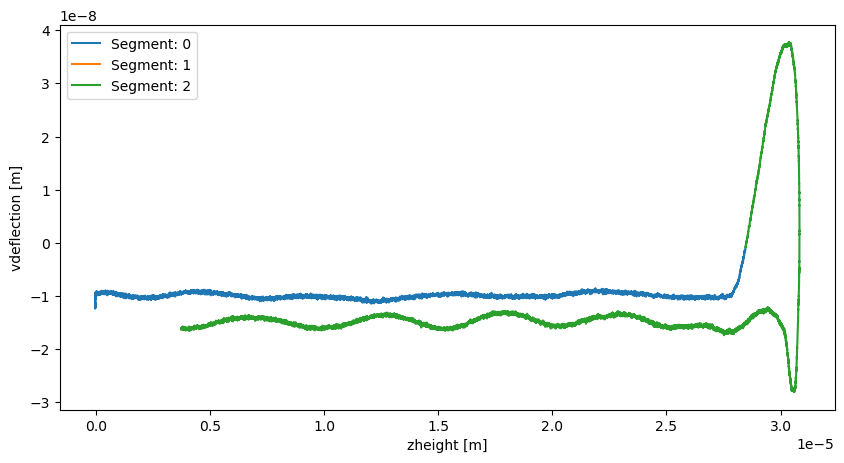

Default


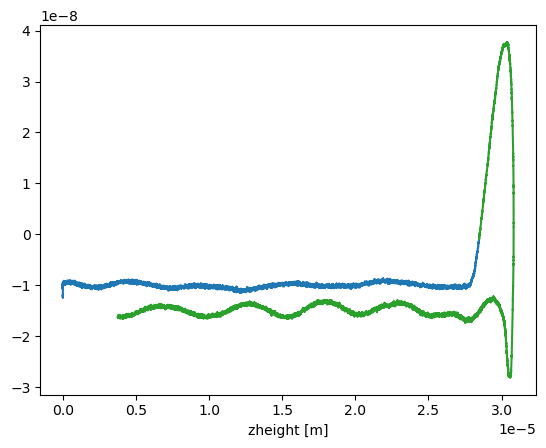

In [5]:
# print(tdms_obj.getcurve)
FC = plotTDMSfile(file_path)

indentation = []
force = []
# for segid, segment in FC.get_segments():
#     indentation.append(segment.identation)
#     force.append(segment.force)
#     print (f'Segment: {segid}')



for segid, segment in FC.get_segments():
        plt.plot(segment.zheight, segment.vdeflection, label=f'Segment: {segid}')
        plt.xlabel('zheight [m]')
        

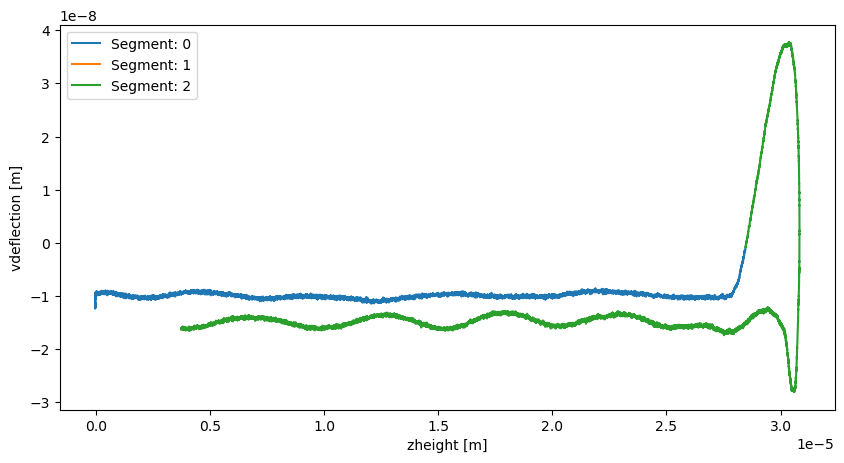

Default


In [6]:
test_path = "/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20.map/fcurve___2025.03.12_18.25.44.81.tdms"
plotTDMSfile(test_path)

In [7]:
from pyfmreader import loadfile
import matplotlib.pyplot as plt
import os

from pyfmrheo import get_poc_RoV_method, doHertzFit  

def analyzeTDMS_hertzFit (PSNEX_PATH:str, param_dict:dict, pts_downsample = 1000, poc_win=100e-8, maxnoncontact = 100e-6, report = False):  
    PSNEX_FILE = loadfile(PSNEX_PATH)
    
    #% Create Default Dictionary
    param_dict = param_dict.copy()
    
    ## LOAD UFF object into FC
    # type(PSNEX_FILE)
    # Load file metadata 
    # metadata = list(PSNEX_FILE.filemetadata.keys())
    metadata = PSNEX_FILE.filemetadata
    # Load Force Curve with segments
    FC = PSNEX_FILE.getcurve(0)
    # curve_metadata = 
    # type (FC)
    
    
    # Get some of the file metadata
    defl_sens = metadata['defl_sens_nmbyV'] / 1e09 # nm/V --> m/V
    # closed_loop = metadata['z_closed_loop']
    
    file_spring_constant = metadata['spring_const_Nbym'] #N/m
    height_channel = metadata['height_channel_key']
    Z_stage_sens_um = metadata['curve_properties']['0'][0]['z_stage_sensitivity'] / 1e03 # nm/V -> um/V
    # print (height_channel)
    FC.preprocess_force_curve(defl_sens, metadata['height_channel_key'])
    
    
    spring_constant = file_spring_constant
    # print(f"Height channel: {Z_stage_sens}")
    # print(f"Height channel: {height_channel}")
    # print(f"Deflection Sens.: {defl_sens} m/V")
    # print(f"Spring Constant: {spring_constant} N/m")
    
    #3. Preprocess curve with the deflection sens in the header
    
    # poc_win=100e-8
    
    
    
    # 8. Get segment 0
    FC_segments = FC.get_segments()
    _, segment = FC_segments[0]
    # type(segment)
    
    
    # pts_downsample = 1000
    downfactor=pts_downsample 
    downfactor= len(segment.zheight) // pts_downsample
    idxDown = list(range(0, len(segment.zheight), downfactor))
    segment.zheight = segment.zheight[idxDown]
    segment.vdeflection = segment.vdeflection[idxDown]
    
    comp_PoC = get_poc_RoV_method(segment.zheight, segment.vdeflection, poc_win)
    # print(comp_PoC)
    
     # coeff, n = get_coeff('paraboloid', 5e-06, self.poisson_ratio)
     # E0 = np.max(force) / coeff / np.max(indentation) ** n
    
    # # plot poc on approach curve
    # plt.figure(figsize=(10,5))
    # for segid, segment in FC.get_segments():
    #     plt.plot(segment.zheight, segment.vdeflection)
    # # plt.plot(comp_PoC[0], comp_PoC[1], 'o')
    # plt.xlabel('zheight [m]')
    # plt.ylabel('vdeflection [m]')
    # plt.legend()
    # plt.show()
    
    # maxnoncontact = 100e-6 #um
    
    default_param_dict = {        
            'height_channel': height_channel,   # Channel where to find the height data
            'def_sens': defl_sens,              # Deflection sensitivity in m/V
            'k': spring_constant,               # Spring constant in N/m
            'contact_model': 'paraboloid',      # Geometry of the indenter: paraboloidal, conical, pyramidal
            'tip_param': 5e-06,                 # Tip raidus in meters or tip angle in degrees
            'curve_seg': 'extend',              # Segement to perform the fit: extend or retract
            'correct_tilt': True,              # Perform tilt correction
            'tilt_min_offset': 1e-08,           # Maximum range where to perform the tilt correction in meters
            'tilt_max_offset': 1e-06,           # Minimum range where to perform the tilt correction in meters
            'poisson': 0.5,                     # Poisson's ratio
            'poc_method': 'RoV',                # Method to find the contact point: RoV or RegulaFalsi
            'poc_win': poc_win,                   # Window size for the RoV method
            'max_ind': 0.0,                     # Maximum indentation range for fit in meters
            'min_ind': 60e-9,                     # Minimum indentation range for fit in meters
            'max_force': 0.0,                   # Maximum force range for fit in Newtons
            'min_force': 2e-9,                   # Minimum force range for fit in Newtons
            'fit_range_type': 'full',           # Fit data range: full, indentation or force
            'd0': comp_PoC[0],                          # Initial point of contact
            'slope': 0.0,                       # Initial slope
            'auto_init_E0': True,               # Estimate automatically the initial value of the Young's Modulus
            'E0': 200,                         # Initial Young's Modulus value
            'f0': comp_PoC[1],                          # Initial F0 value
            'contact_offset': maxnoncontact,    # Baseline offset for the Hertz Fit
            'fit_line': False,                  # Fit line to the baseline
            'downsample_flag': True,            # Downsample the signal for Hertz Fit
            'pts_downsample': pts_downsample,   # Number of points to downsample
            'offset_type':'percentage',         # How to correct for baseline offset: percentage or value
            'max_offset':0.3,                    # Max percentage to compute offset
            'min_offset':0.2                     # Min percentage to compute offset
        }
    # param_dict = {

    # }
    
    
    #Update param dict     
    for key, value in default_param_dict.items():
        if key not in param_dict.keys():
            param_dict[key] = value
    
    
    FC.shift_height()
    # Select curve by index
    # curve_idx = 0
    # force_curve = PSNEX_FILE.getcurve(curve_idx)
    # Preprocess curve
    FC.preprocess_force_curve(param_dict['def_sens'], param_dict['height_channel'])
    # # JPK files require the height signal to be shifted
    # if metadata['file_type'] in ('jpk-force', 'jpk-force-map', 'jpk-qi-data'):
    #     force_curve.shift_height()
    
    # Run fit
    hertz_result = doHertzFit(FC, param_dict)
    
    # Check Hertz Result values
    if report == True:
        hertz_result.fit_report()
    
    # Get parameters from fit
    d0 = hertz_result.delta0
    f0 = hertz_result.f0
    
    # Prepare data for plotting
    segs = FC.get_segments()
    ext_data = segs[0][1]
    indentation = ext_data.indentation
    force = ext_data.force
    fit_mask = indentation > (-1 * maxnoncontact)
    ind_fit = indentation[fit_mask]
    force_fit = force[fit_mask]
    force_fit = force_fit 
    downfactor= len(ext_data.indentation) // pts_downsample
    idxDown = list(range(0, len(ind_fit), 1))
    
   
    # Plot Hertz Fit
    plt.plot(
        (ind_fit[idxDown]) * 1e9,
        force_fit[idxDown] * 1e12,
        color='#E72E38',
        linewidth=3,
        label='Experimental Data'
    )
    
    plt.plot(
        (ind_fit[idxDown]) * 1e9,
        (hertz_result.eval(
            ind_fit[idxDown]
            ) - f0) * 1e12,
        color='#2B3E51',
        linewidth=2.5,
        linestyle='--',
        label='Viscoeelastic Model Fit'
    )
    title = os.path.split(PSNEX_PATH[:-5])
    folder = os.path.split(title[0])
    plt.title(folder[1][:-12] +' : '+ title[1])
    plt.xlabel('Indentation [nm]', fontsize = 15)
    plt.ylabel('Force [pN]', fontsize = 15)
    # plt.legend()
    plt.show()
    return param_dict, FC, comp_PoC, metadata


/Users/evillz/.local/share/mamba/envs/pyfmgui_tether_GUI/lib/python3.9/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


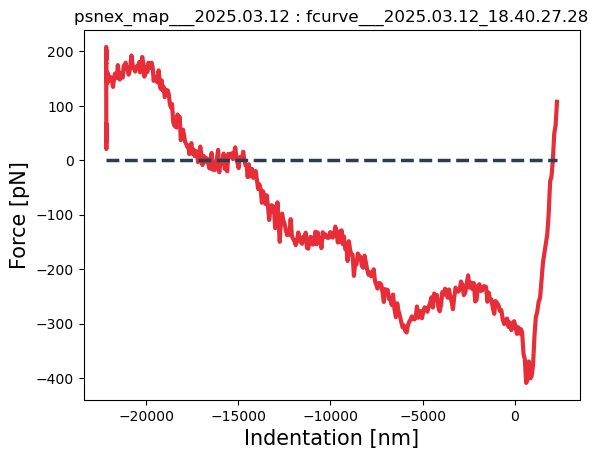

In [8]:
param_dict = {        

        'contact_model': 'paraboloid',      # Geometry of the indenter: paraboloidal, conical, pyramidal
        'tip_param':75e-09,                 # Tip raidus in meters or tip angle in degrees
        'curve_seg': 'Approach',              # Segement to perform the fit: extend or retract
        'correct_tilt': False,              # Perform tilt correction
        'tilt_min_offset': 1e-08,           # Maximum range where to perform the tilt correction in meters
        'tilt_max_offset': 1e-06,           # Minimum range where to perform the tilt correction in meters
        'poisson': 0.5,                     # Poisson's ratio
        'poc_method': 'RoV',                # Method to find the contact point: RoV or RegulaFalsi
        'max_ind': 0.0,                     # Maximum indentation range for fit in meters
        'min_ind': 60e-12,                     # Minimum indentation range for fit in meters
        'max_force': 0.0,                   # Maximum force range for fit in Newtons
        'min_force': 100-12,                   # Minimum force range for fit in Newtons
        'fit_range_type': 'full',           # Fit data range: full, indentation or force
        'slope': 0.0,                       # Initial slope
        'auto_init_E0': True,               # Estimate automatically the initial value of the Young's Modulus
        'E0': 100,                         # Initial Young's Modulus value
        'fit_line': True,                  # Fit line to the baseline
        'downsample_flag': True,            # Downsample the signal for Hertz Fit
        'offset_type':'percentage',         # How to correct for baseline offset: percentage or value
        'max_offset':0.2,                    # Max percentage to compute offset
        'min_offset':0.1,                     # Min percentage to compute offset
    }

test_path = "/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20.map/fcurve___2025.03.12_18.25.44.81.tdms"
test_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/fcurve___2025.03.12_18.40.27.28.tdms'
param_dict,_,_,metadta = analyzeTDMS_hertzFit(test_path, param_dict = {}, maxnoncontact = 100e-6,
                                              pts_downsample = 500, poc_win = 600e-9, report = False)

# print(param_dict)

In [ ]:
# # Import Bokeh modules for interactive plotting
# import bokeh.io
# import bokeh.models
# import bokeh.palettes
# import bokeh.plotting

# import bootcamp_utils

# # Display graphics in this notebook
# bokeh.io.output_notebook()

ModuleNotFoundError: No module named 'bootcamp_utils'

In [ ]:
# import pyqtgraph as pg
# from pyqtgraph.Qt import QtWidgets
# import numpy as np
# import sys

# from pyfmreader.ps_nex.parseTDMS import parse_tdms


# FC = plotTDMSfile(file_path)


# # Set up the application window
# app = QtWidgets.QApplication([])

# indentation = []
# force = []
# # for segid, segment in FC.get_segments():
# #     indentation.append(segment.identation)
# #     force.append(segment.force)
# #     print (f'Segment: {segid}')

# # Create the plot widget
# colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Define a list of colors

# plot_win = pg.PlotWidget(title="Multiple Graphs on One Plot")

# for i, (segid, segment) in enumerate(FC.get_segments()):
#         color = colors[i % len(colors)]  # Cycle through the colors list
#         plot_win.plot(segment.zheight, segment.vdeflection, name=f'Segment: {segid}', pen=color)
# plot_win.show()
# app.exec_()
# # Ensure the app shuts down cleanly
# try:
#     sys.exit(app.exec_())
# except SystemExit:
#     print("Closing PyQtGraph properly!")
        

In [ ]:
# from pyfmreader.ps_nex.parseTDMS import parse_tdms
# from pyfmreader.ps_nex.loadpsnexfile import loadPSNEXfile
# from pyfmreader.uff import UFF

# from nptdms import TdmsFile
# file_path = '/Users/evillz/Data/psnex_map___2025.03.12_18.23.11.20.map/fcurve___2025.03.12_18.25.44.81.tdms'

# ffobj = UFF()

# uff = loadPSNEXfile(file_path, ffobj)
# metadata = uff.filemetadata

# # Get Channel Names
# TDMS_channel_names = TdmsFile.open(uff.filemetadata['file_path']).groups()[0].channels()

# channel_names = [channel.name for channel in TDMS_channel_names]
# print(channel_names)

# channel_deflection = channel_names[0]
# channel_z = channel_names[1]


# channel_data_deflection, channel_data_piezo, time_ms = parse_tdms(file_path, deflectionChannel= channel_deflection, zDisplacement=channel_z)
# time_s = time_ms/1000
# print(time_s)

import pyqtgraph as pg
from pyqtgraph.Qt import QtWidgets
import numpy as np
import sys

# Set up PyQtGraph app
app = QtWidgets.QApplication([])

# Create window with two plots
win = pg.GraphicsLayoutWidget(title="Multiple Graphs Example")
p1 = win.addPlot(title="deflection")
# p1.plot(time_s, channel_data_deflection, pen='r')
# p1.plot(time_s, channel_data_piezo, pen='b')
p1.plot(channel_data_piezo, channel_data_deflection, pen= 'b')

win.show()

# Ensure the app shuts down cleanly
try:
    sys.exit(app.exec())
except SystemExit:
    print("Closing PyQtGraph properly!")